# PS-S06E06: NN - Tabular ResNet (Embeddings)

This notebook tackles the [**Playground Series - Season 6, Episode 6: Predicting Stellar Class**](https://www.kaggle.com/competitions/playground-series-s6e6), a competition focused on predicting a class label (`GALAXY`, `QSO`, `STAR`) for the `class` target, based on features describing the position, light intensity across SDSS photometric bands, redshift, spectral type, and galaxy population for each observed object.

**Task**
* Three-class classification: predict **GALAXY**, **QSO**, or **STAR**
* Target column: `class`
* Evaluation metric: **Balanced Accuracy**
* Submission format: hard class label per row

**Model**
* Tabular neural network with:
    * Numeric features (photometric bands, redshift, engineered colour indices)
    * Embedded categorical features (`spectral_type`, `galaxy_population`)
    * Residual MLP backbone
* Trained using stratified cross-validation
* Final predictions are averaged (soft) across folds then decoded to class labels

This notebook is one of a number of notebooks that explore various models to address this challenge. The EDA was performed in: [**PS-S06E06: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e06-eda).

## Import Needed Packages

In [1]:
import os
import gc
import sys
import copy
import math
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import balanced_accuracy_score
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e06_feature_engineering import FeatureFactory
from ps_s06e06_model_visualizer import ModelVisualizer
from ps_s06e06_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [2]:
setup = ExperimentSetup(
    model_name='NN Tabular ResNet',
    use_gpu=True,
)

seed = setup.set_seeds()

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    
setup.configure_pandas()
setup.suppress_warnings()

# The target feature
TARGET = 'class'

# Class label mapping - must be consistent everywhere
target_mapping = {'QSO': 0, 'STAR': 1, 'GALAXY': 2}
inverse_target_mapping = {v: k for k, v in target_mapping.items()}
N_CLASSES = 3

setup.describe()

Random seed set to: 10301
Warnings suppressed.

Experiment Setup
Model         : NN Tabular ResNet
Target        : class
Use GPU       : True
RFE           : False
Optuna Tuning : False 
On Kaggle     : False


## Read and Examine the Training Dataset

### Dataset Description
The dataset contains photometric and spectroscopic measurements from the Sloan Digital Sky Survey (SDSS).

**Key characteristics**
* Mixed numeric (`u`, `g`, `r`, `i`, `z` magnitudes, `redshift`, `alpha`, `delta`) and categorical (`spectral_type`, `galaxy_population`) inputs
* Large dataset (~577k training rows) - well-suited for neural network training
* Target labels are strings: `GALAXY`, `QSO`, `STAR`

**Target encoding**
* `QSO` &rarr; 0
* `STAR` &rarr; 1
* `GALAXY` &rarr; 2


In [3]:
training_df = setup.get_combined_training_data()
train_ids = training_df['id'].copy()

TRAINING DATASET

   id   alpha  delta      u      g      r      i      z  redshift  \
0   0 147.734 16.959 25.472 21.896 20.358 19.257 18.621     0.409   
1   1 127.989 32.347 20.779 19.087 17.587 17.226 16.786     0.158   
2   2 179.793 35.345 21.035 21.079 21.172 20.583 20.557     2.824   
3   3 225.818 48.569 23.305 21.051 19.018 18.366 17.915     0.536   
4   4 141.836 19.343 21.703 19.472 18.234 17.899 17.616     0.556   

  spectral_type galaxy_population   class  
0             M      Red_Sequence  GALAXY  
1             M      Red_Sequence  GALAXY  
2           O/B        Blue_Cloud     QSO  
3             M      Red_Sequence  GALAXY  
4             M      Red_Sequence  GALAXY  


## Read and Examine the Test Dataset

In [4]:
test_df = setup.read_dataset('test')
test_ids  = test_df['id'].copy()

TEST DATASET

       id   alpha  delta      u      g      r      i      z  redshift  \
0  577347 120.720 23.924 23.668 21.952 21.086 20.180 19.202     0.429   
1  577348 219.414 42.172 24.903 22.339 20.732 19.860 19.688     0.867   
2  577349 173.569 -1.756 19.428 18.475 17.551 16.571 16.177     0.224   
3  577350 184.904 -1.411 23.121 21.527 20.670 20.418 20.699     0.067   
4  577351 222.488 15.381 25.094 22.644 21.123 19.440 19.094     0.977   

  spectral_type galaxy_population  
0           G/K      Red_Sequence  
1             M      Red_Sequence  
2           G/K        Blue_Cloud  
3           G/K      Red_Sequence  
4             M      Red_Sequence  


## Feature Engineering Strategy
Feature engineering is intentionally conservative to preserve signal for the neural network.

### Applied strategies
* **`encoding`** - Casts `spectral_type` (ordered O/B&rarr;M) and `galaxy_population` to `category` dtype so the encoder can build embedding tables for them
* **`colors`** - SDSS photometric colour indices (`u-g`, `g-r`, `r-i`, `i-z`, wider-baseline combos). The primary class discriminators in colour-colour space
* **`ratios`** - SED shape features: mean/std magnitude, spectral slope, outer-to-central band ratio
* **`redshift`** - Redshift-derived features and colour&times;redshift interactions. Redshift is the single strongest discriminator in this dataset
* **`position`** - Cartesian sky-coordinate projection and |δ|

### Not applied
* **`interactions`** - Higher-order cross-products are omitted; the residual network can learn these internally
* **Standard scaling** - Applied inside the training loop per-fold to prevent leakage, not in the FeatureFactory

### Categorical handling
* `spectral_type` and `galaxy_population` are passed as integer codes to embedding layers. Embeddings are learned directly by the network - no one-hot encoding needed.

In [5]:
# Define which strategies to use for the LightGBM model here:
fe_strategies = [
    'encoding',       # Cast spectral_type and galaxy_population to category dtype
    'colors',         # SDSS photometric colour indices
    'ratios',         # SED shape features: mean/std magnitude, spectral slope
    'redshift',       # Redshift-derived features and colour×redshift interactions
    'position',       # Sky-coordinate Cartesian projection and |delta|
    'interactions',   # Higher-order cross-feature products
    'flux',
    'numeric_expansion'
]

In [6]:
print('Performing initial feature engineering.')

# Encode target: QSO=0, STAR=1, GALAXY=2
y = training_df[TARGET].map(target_mapping).astype(np.int64).values

feature_engineer = FeatureFactory(
    strategies=fe_strategies,
    target=TARGET,
    seed=seed
)

X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

cat_features = feature_engineer.get_cat_features(X)
print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(f'Cat features for NN embeddings ({len(cat_features)}): {cat_features}')
print(X.head())


Performing initial feature engineering.
Old Feature Count: 9
New Feature Count: 66
Cat features for NN embeddings (3): ['spectral_type', 'galaxy_population', 'sky_bin']
    alpha  delta      u      g      r      i      z  redshift spectral_type  \
0 147.734 16.959 25.472 21.896 20.358 19.257 18.621     0.409             M   
1 127.989 32.347 20.779 19.087 17.587 17.226 16.786     0.158             M   
2 179.793 35.345 21.035 21.079 21.172 20.583 20.557     2.824           O/B   
3 225.818 48.569 23.305 21.051 19.018 18.366 17.915     0.536             M   
4 141.836 19.343 21.703 19.472 18.234 17.899 17.616     0.556             M   

  galaxy_population  u_minus_g  g_minus_r  r_minus_i  i_minus_z  u_minus_r  \
0      Red_Sequence      3.577      1.538      1.101      0.636      5.114   
1      Red_Sequence      1.691      1.500      0.361      0.440      3.191   
2        Blue_Cloud     -0.044     -0.093      0.589      0.025     -0.137   
3      Red_Sequence      2.254      2.033   

### Model Training: Neural Network Strategy (3-Class Classification)

Model training is performed using **5-Fold Stratified Cross-Validation**.

1. **Feature Scaling and Input Preparation**
   * Numeric features are standardized per-fold to prevent leakage.
   * Categorical features (`spectral_type`, `galaxy_population`) are integer-encoded and passed to embedding layers.
   * Target is encoded as QSO=0, STAR=1, GALAXY=2.

2. **Stratified Cross-Validation**
   * `StratifiedKFold` preserves class proportions across all three stellar classes in every fold.
   * Out-of-fold **probability matrices** (N&times;3) are stored for unbiased evaluation and blending.

3. **Optimization Objective**
   * The model is trained using **CrossEntropyLoss** (the standard multi-class objective).
   * The network outputs raw logits of shape `(batch, 3)`; softmax is applied during evaluation.
   * Model performance is evaluated using **Balanced Accuracy**, matching the competition metric.

4. **Adaptive Learning and Early Stopping**
   * **CosineAnnealingWarmRestarts** provides a cyclic LR schedule.
   * **Early stopping** is applied based on validation Balanced Accuracy.
   * Best model weights per fold are restored before inference.


In [7]:
def fit_nn_encoders(X_train: pd.DataFrame, X_ref: pd.DataFrame, cat_cols: list):
    """
    Fit categorical mappings using X_train + X_ref (usually X_test) so test categories are known.
    Return mappings and numeric column list.
    """
    X_all = pd.concat([X_train[cat_cols], X_ref[cat_cols]], axis=0, ignore_index=True)

    cat_maps = {}
    cat_dims = []
    for c in cat_cols:
        s = X_all[c].astype(str).fillna("__nan__")
        uniq = pd.Index(s.unique())
        cat_maps[c] = {k: i for i, k in enumerate(uniq)}
        cat_dims.append(len(uniq))

    num_cols = [c for c in X_train.columns if c not in cat_cols]
    return {"cat_cols": cat_cols, "num_cols": num_cols, "cat_maps": cat_maps, "cat_dims": cat_dims}


def transform_with_encoders(X: pd.DataFrame, fitted):
    cat_cols = fitted["cat_cols"]
    num_cols = fitted["num_cols"]
    cat_maps = fitted["cat_maps"]

    X_num = X[num_cols].to_numpy(dtype=np.float32)

    X_cat = np.zeros((len(X), len(cat_cols)), dtype=np.int64)
    for j, c in enumerate(cat_cols):
        m = cat_maps[c]
        s = X[c].astype(str).fillna("__nan__")
        X_cat[:, j] = s.map(lambda v: m.get(v, 0)).to_numpy(dtype=np.int64)

    return X_num, X_cat


In [8]:
class ResNetBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super(ResNetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, input_dim),
            nn.BatchNorm1d(input_dim)
        )
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class TabularResNet(nn.Module):
    def __init__(self, num_dim, cat_dims, n_classes=3, hidden_dim=512, dropout_rate=0.2, num_blocks=6):
        super(TabularResNet, self).__init__()

        # Embedding layers for categoricals
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_cats, emb_dim)
            for num_cats, emb_dim in cat_dims
        ])

        total_cat_dim = sum(emb_dim for _, emb_dim in cat_dims)
        combined_dim = num_dim + total_cat_dim

        self.input_layer = nn.Linear(combined_dim, hidden_dim)
        self.bn0 = nn.BatchNorm1d(hidden_dim)

        self.blocks = nn.ModuleList([
            ResNetBlock(hidden_dim, hidden_dim, dropout_rate)
            for _ in range(num_blocks)
        ])

        # Output head: n_classes logits (was 1 for binary)
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Linear(128, n_classes)   # 3 outputs for QSO / STAR / GALAXY
        )

    def forward(self, x_num, x_cat):
        embedded_cats = [
            emb_layer(x_cat[:, i])
            for i, emb_layer in enumerate(self.embeddings)
        ]
        x = torch.cat(embedded_cats + [x_num], dim=1)
        x = self.input_layer(x)
        x = self.bn0(x)
        for block in self.blocks:
            x = block(x)
        return self.output_head(x)   # raw logits, shape (batch, 3)


In [9]:
class TabularDataset(torch.utils.data.Dataset):
    """Handles dual numeric + categorical inputs for multi-class targets."""
    def __init__(self, x_num, x_cat, y=None):
        self.x_num = torch.FloatTensor(x_num)
        self.x_cat = torch.LongTensor(x_cat)
        # y is class index (int64) for CrossEntropyLoss
        self.y = torch.LongTensor(y) if y is not None else None

    def __len__(self):
        return len(self.x_num)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.x_num[idx], self.x_cat[idx], self.y[idx]
        return self.x_num[idx], self.x_cat[idx]


### Evaluation Metric
**Primary metric: Balanced Accuracy**
* Computed as the arithmetic mean of per-class recall across QSO, STAR, and GALAXY
* Uses **predicted class labels** (argmax of softmax probabilities)
* Matches the Kaggle leaderboard scoring for this competition

**Why Balanced Accuracy**
* Accounts for class imbalance - GALAXY rows outnumber QSO and STAR
* Penalises models that ignore minority classes
* A model that always predicts GALAXY would score only ~0.33


In [10]:
# Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

# Hyperparameters
BATCH_SIZE = 1024
EPOCHS = 200
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

# OOF: (N, 3) probability matrix
oof_probs  = np.zeros((len(training_df), N_CLASSES), dtype=np.float32)
test_probs = np.zeros((len(test_df), N_CLASSES), dtype=np.float32)
history = {'train_loss': [], 'val_bal_acc': [], 'lrs': []}
scores = []

print(f'Starting Training with {n_folds} folds...')

for fold, (train_idx, val_idx) in enumerate(skf.split(training_df, y), 1):
    print(f'\n=== Fold {fold}/{n_folds} ===')

    X_train_df = training_df.iloc[train_idx].copy()
    X_val_df   = training_df.iloc[val_idx].copy()
    y_train    = y[train_idx]
    y_val      = y[val_idx]

    # Fit FE on train fold only - prevents leakage
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed + fold)
    X_tr_full = fe_fold.fit_transform(X_train_df)
    X_va_full = fe_fold.transform(X_val_df)
    X_te_full = fe_fold.transform(test_df)

    X_tr = X_tr_full.drop(columns=[TARGET], errors='ignore')
    X_va = X_va_full.drop(columns=[TARGET], errors='ignore')
    X_te = X_te_full.drop(columns=[TARGET], errors='ignore')

    cat_features = fe_fold.get_cat_features(X_tr)
    fitted = fit_nn_encoders(X_tr, X_te, cat_features)

    Xtr_num_np, Xtr_cat_np = transform_with_encoders(X_tr, fitted)
    Xva_num_np, Xva_cat_np = transform_with_encoders(X_va, fitted)
    Xte_num_np, Xte_cat_np = transform_with_encoders(X_te, fitted)

    # Scale numerics per-fold
    scaler = StandardScaler()
    Xtr_num_np = scaler.fit_transform(Xtr_num_np)
    Xva_num_np = scaler.transform(Xva_num_np)
    Xte_num_np = scaler.transform(Xte_num_np)

    cat_dims = [(n, min(16, int(np.ceil(np.sqrt(n))))) for n in fitted["cat_dims"]]
    num_dim  = Xtr_num_np.shape[1]

    train_ds = TabularDataset(Xtr_num_np, Xtr_cat_np, y_train)
    val_ds   = TabularDataset(Xva_num_np, Xva_cat_np, y_val)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    model = TabularResNet(
        num_dim=num_dim,
        cat_dims=cat_dims,
        n_classes=N_CLASSES,
        hidden_dim=512,
        num_blocks=6,
        dropout_rate=0.3,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    # Correct inverse-frequency class weights as per AGENTS.md
    class_counts = np.bincount(y_train)
    weights = 1.0 / class_counts
    class_weights = torch.tensor(weights / weights.sum(), dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )
    
    best_val_bal_acc  = -1.0
    best_model_weights = copy.deepcopy(model.state_dict())
    patience_counter  = 0
    ES_PATIENCE = 30

    progress_bar = tqdm(range(EPOCHS), desc=f'Fold {fold}', leave=True)

    for epoch in progress_bar:
        # ── Train ────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0

        for batch_num, batch_cat, batch_y in train_loader:
            batch_num = batch_num.to(device)
            batch_cat = batch_cat.to(device)
            batch_y   = batch_y.to(device)   # LongTensor class indices

            optimizer.zero_grad()
            logits = model(batch_num, batch_cat)   # (batch, 3)
            loss   = criterion(logits, batch_y)    # CrossEntropyLoss expects (N,C) vs (N,)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * len(batch_y)

        scheduler.step()
        epoch_loss = running_loss / len(train_ds)

        # ── Validate ────────────────────────────────────────────────────────
        model.eval()
        val_logits_list = []
        val_labels_list = []

        with torch.no_grad():
            for batch_num, batch_cat, batch_y in val_loader:
                batch_num = batch_num.to(device)
                batch_cat = batch_cat.to(device)
                logits = model(batch_num, batch_cat)
                val_logits_list.append(logits.cpu())
                val_labels_list.append(batch_y)

        val_logits = torch.cat(val_logits_list, dim=0)         # (N_val, 3)
        val_probs  = torch.softmax(val_logits, dim=1).numpy()  # (N_val, 3)
        val_preds  = np.argmax(val_probs, axis=1)
        val_labels = torch.cat(val_labels_list).numpy()

        val_bal_acc = balanced_accuracy_score(val_labels, val_preds)

        history['train_loss'].append(epoch_loss)
        history['val_bal_acc'].append(val_bal_acc)
        history['lrs'].append(scheduler.get_last_lr()[0])

        progress_bar.set_postfix({'loss': f'{epoch_loss:.4f}', 'val_bal_acc': f'{val_bal_acc:.5f}'})

        # ── Early stopping ────────────────────────────────────────────────────
        # Track best weights on every epoch, but only start counting patience after epoch 20 (as per AGENTS.md)
        if val_bal_acc > best_val_bal_acc:
            best_val_bal_acc  = val_bal_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter  = 0
        else:
            current_lr = scheduler.get_last_lr()[0]
            # Only count patience when learning rate is low (below 20% of initial LR) to avoid warm-restart troughs
            if epoch >= 20 and current_lr < 0.2 * LEARNING_RATE:
                patience_counter += 1
                if patience_counter >= ES_PATIENCE:
                    print(f'  Early stopping at epoch {epoch + 1}')
                    break
            
    # ── Fold inference ────────────────────────────────────────────────────
    model.load_state_dict(best_model_weights)
    model.eval()

    with torch.no_grad():
        # OOF probabilities
        val_num_t  = torch.tensor(Xva_num_np, dtype=torch.float32).to(device)
        val_cat_t  = torch.tensor(Xva_cat_np, dtype=torch.long).to(device)
        val_logits = model(val_num_t, val_cat_t)
        val_probs  = torch.softmax(val_logits, dim=1).cpu().numpy()
        oof_probs[val_idx] = val_probs

        # Test probabilities (accumulated, averaged at end)
        te_num_t   = torch.tensor(Xte_num_np, dtype=torch.float32).to(device)
        te_cat_t   = torch.tensor(Xte_cat_np, dtype=torch.long).to(device)
        te_logits  = model(te_num_t, te_cat_t)
        te_probs   = torch.softmax(te_logits, dim=1).cpu().numpy()
        test_probs += te_probs / n_folds

    fold_preds = np.argmax(val_probs, axis=1)
    fold_score = balanced_accuracy_score(y_val, fold_preds)
    scores.append(fold_score)
    print(f'  Fold {fold} Best Balanced Accuracy: {fold_score:.5f}')

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

oof_preds  = np.argmax(oof_probs, axis=1)
overall_score = balanced_accuracy_score(y, oof_preds)
print(f'\nOverall CV Balanced Accuracy: {overall_score:.5f}')


Training on: cuda
Starting Training with 5 folds...

=== Fold 1/5 ===


Fold 1:   0%|          | 0/200 [00:00<?, ?it/s]

  Early stopping at epoch 140
  Fold 1 Best Balanced Accuracy: 0.95883

=== Fold 2/5 ===


Fold 2:   0%|          | 0/200 [00:00<?, ?it/s]

  Early stopping at epoch 140
  Fold 2 Best Balanced Accuracy: 0.95875

=== Fold 3/5 ===


...

  Early stopping at epoch 140
  Fold 3 Best Balanced Accuracy: 0.95877

=== Fold 4/5 ===


Fold 4:   0%|          | 0/200 [00:00<?, ?it/s]

  Early stopping at epoch 140
  Fold 4 Best Balanced Accuracy: 0.95765

=== Fold 5/5 ===


Fold 5:   0%|          | 0/200 [00:00<?, ?it/s]

  Early stopping at epoch 140
  Fold 5 Best Balanced Accuracy: 0.95817

Overall CV Balanced Accuracy: 0.95844


## Visualizing Model Performance
The following diagnostics are generated using out-of-fold predictions:
* Training heartbeat (loss + Balanced Accuracy per epoch)
* Confusion matrix
* ROC curves (one-vs-rest)
* Distribution mismatch across the three stellar classes


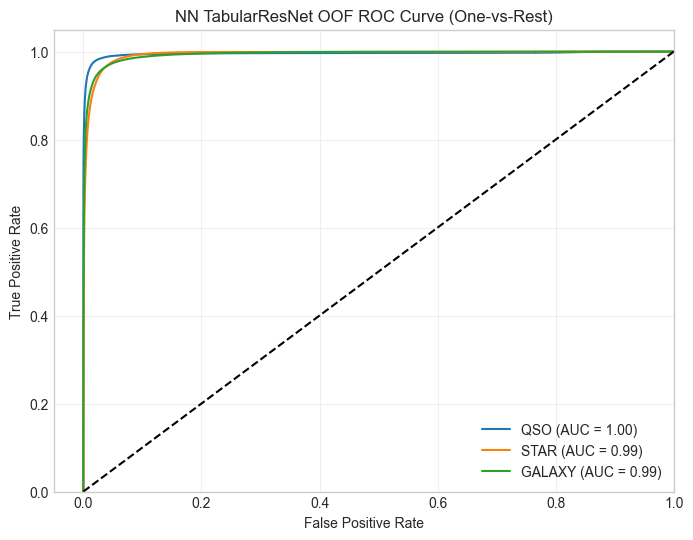

In [11]:
mviz = ModelVisualizer(model_name='NN TabularResNet')

mviz.plot_multiclass_roc_curve(
    y_true=y,
    y_score=oof_probs,
    title='NN TabularResNet OOF ROC Curve (One-vs-Rest)'
)

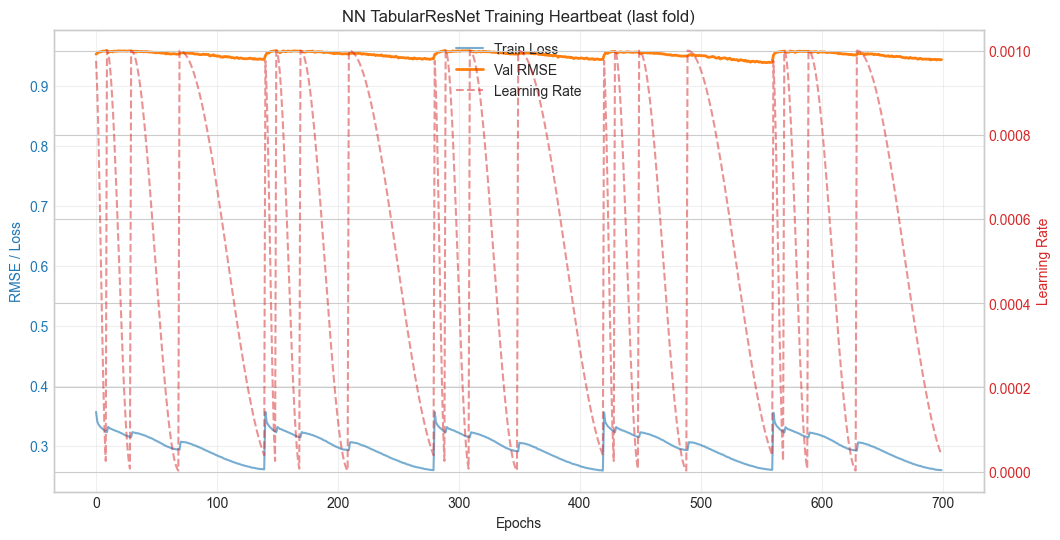

In [12]:
# Rename key to match ModelVisualizer's expected 'val_rmse' slot
# (ModelVisualizer was built for regression; we re-use it with our metric)
heartbeat_history = {
    'train_loss': history['train_loss'],
    'val_rmse':   history['val_bal_acc'],   # display as validation metric
    'lrs':        history['lrs'],
}
mviz.plot_training_heartbeat(heartbeat_history, title_suffix='(last fold)')

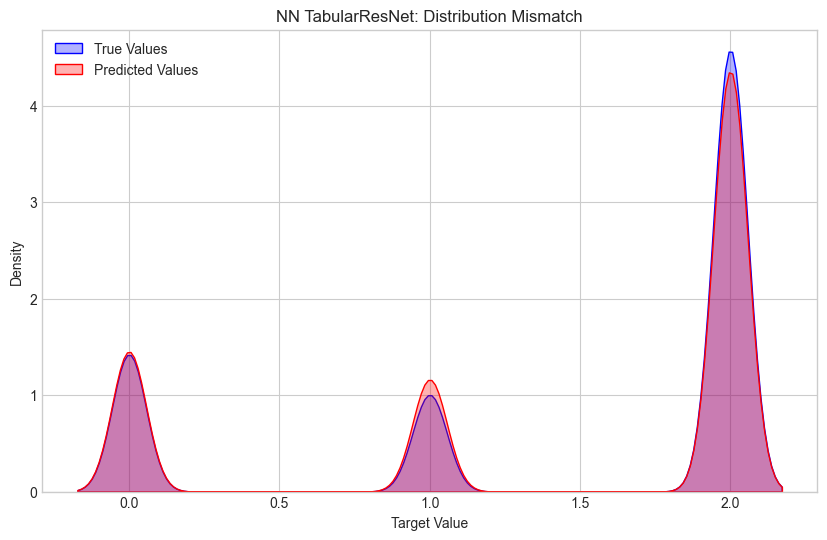

In [13]:
# Distribution of OOF predicted class vs true class (integer-encoded)
mviz.plot_distribution_mismatch(y_true=y, y_preds=oof_preds)

Normalized confusion matrix


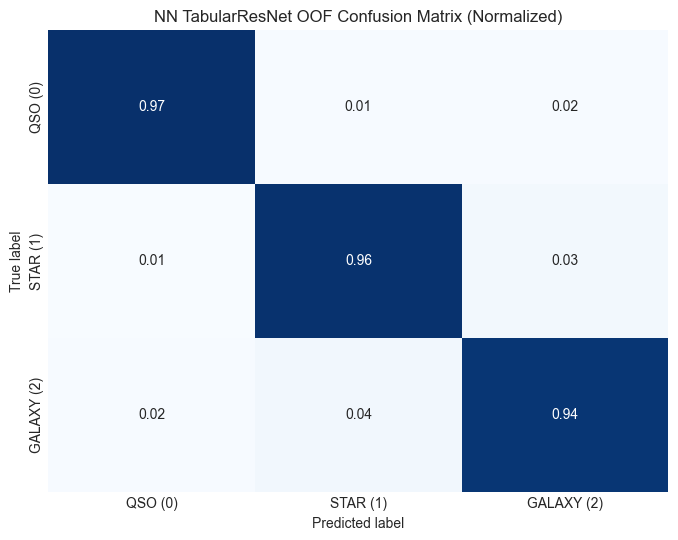

In [14]:
mviz.plot_confusion_matrix(
    y_true=y,
    y_pred=oof_preds,
    classes=['QSO (0)', 'STAR (1)', 'GALAXY (2)'],
    normalize=True,
    title='NN TabularResNet OOF Confusion Matrix (Normalized)'
)

## Prepare Submission

The competition requires a hard predicted class label (`GALAXY`, `QSO`, or `STAR`) for each test row. We derive predictions by taking the argmax of the averaged test probabilities and mapping back to the original string labels.

In [15]:
submission_df = setup.read_dataset('submission')
target_col = [c for c in submission_df.columns if c != 'id'][0]

numeric_preds = np.argmax(test_probs, axis=1)
submission_df[target_col] = pd.Series(numeric_preds).map(inverse_target_mapping)

print('SAMPLE SUBMISSION')
print('=================')
print(submission_df.head(10))

print('\nPredicted Class Distribution:')
print(submission_df[target_col].value_counts(normalize=True).sort_index())


SAMPLE SUBMISSION
       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
5  577352  GALAXY
6  577353  GALAXY
7  577354    STAR
8  577355  GALAXY
9  577356  GALAXY

Predicted Class Distribution:
class
GALAXY   0.626
QSO      0.208
STAR     0.166
Name: proportion, dtype: float64


In [16]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) **probability matrices** (N&times;3) and averaged test-set **probability matrices** are saved for downstream blending and stacking.

These files are used to:
- Compare model performance using OOF Balanced Accuracy
- Analyze correlation and complementarity between models
- Serve as inputs to the blending and stacking notebooks

Each file contains raw, un-thresholded probabilities for all three classes. This is essential for weighted blending, stacking, and calibration analysis.

Column names match the convention used by the other model notebooks:
`prob_qso`, `prob_star`, `prob_galaxy`

In [17]:
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Column names match the class label mapping: QSO=0, STAR=1, GALAXY=2
prob_cols = ['prob_qso', 'prob_star', 'prob_galaxy']

# OOF probabilities
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)
oof_out = pd.concat([
    pd.DataFrame({'id': train_ids.values, 'target': y}),
    oof_prob_df
], axis=1)
oof_out.to_csv(f'{output_dir}/nn_tabular_resnet_oof_probs.csv', index=False)

# Test probabilities
test_prob_df = pd.concat([
    pd.DataFrame({'id': test_ids.values}),
    pd.DataFrame(test_probs, columns=prob_cols)
], axis=1)
test_prob_df.to_csv(f'{output_dir}/nn_tabular_resnet_test_probs.csv', index=False)

print(f'Saved for blending/stacking:')
print(f'  {output_dir}/nn_tabular_resnet_oof_probs.csv')
print(f'  {output_dir}/nn_tabular_resnet_test_probs.csv')


Saved for blending/stacking:
  predictions/nn_tabular_resnet_oof_probs.csv
  predictions/nn_tabular_resnet_test_probs.csv
